In [84]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import xtrack as xt
import xobjects as xo
from cpymad.madx import Madx

folder = Path('Lattice_Files/00_Simplified_Lattice/')
madx = Madx(stdout=False)
madx.call(str(folder / 'ISIS.injected_beam'))
madx.call(str(folder / 'ISIS.elements'))
madx.call(str(folder / 'ISIS.strength'))
madx.call(str(folder / 'ISIS.sequence'))

In [85]:
madx.use('synchrotron')
madx.command.select(flag='makethin', slice=1, thick=False)
madx.command.makethin(sequence='synchrotron', style='teapot', makedipedge=True)

True

In [86]:
context = xo.ContextCpu()

line = xt.Line.from_madx_sequence(madx.sequence.synchrotron)
line.set_particle_ref('proton', kinetic_energy0=70e6)
line.build_tracker()

Converting sequence "synchrotron":   0%|          | 0/586 [00:00<?, ?it/s]

In [80]:
n_particles = int(1e3)
particles = xt.Particles(
    x=np.random.normal(0, 1e-6, n_particles),
    px=np.random.normal(0, 1e-6, n_particles),
    y=np.random.normal(0, 1e-6, n_particles),
    py=np.random.normal(0, 1e-6, n_particles),
    zeta=np.random.normal(0, 1e-5, n_particles),
    delta=np.random.normal(0, 1e-5, n_particles)
)

In [81]:
n_turns = 100
line.track(particles, num_turns=n_turns, turn_by_turn_monitor=True)

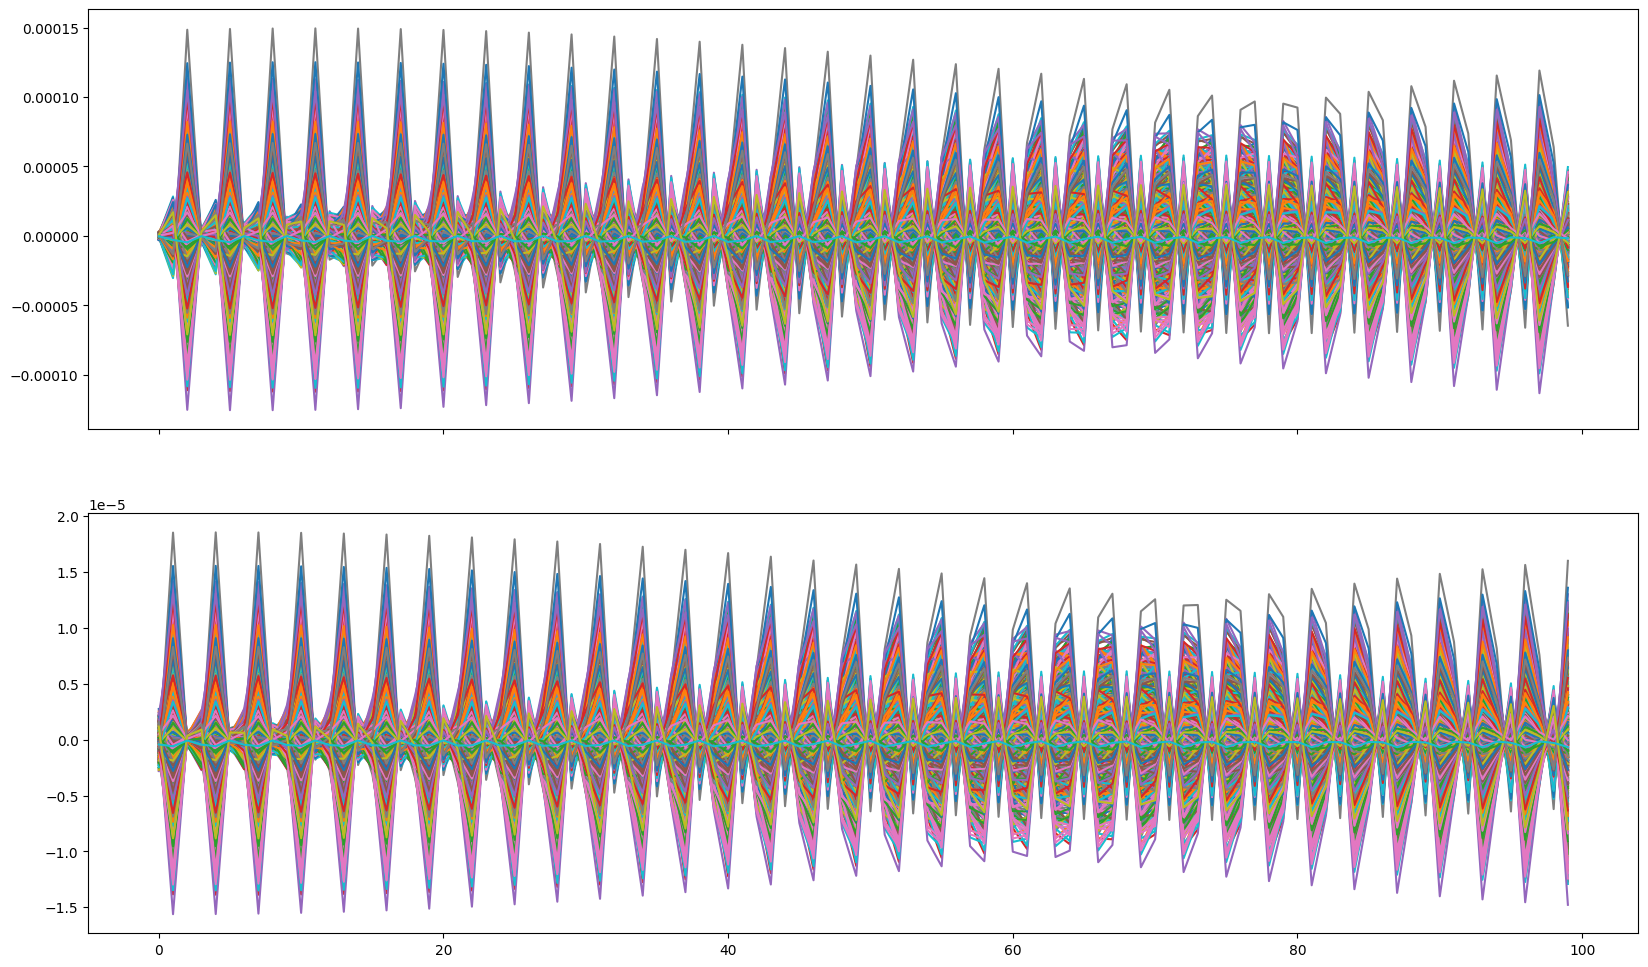

In [82]:
x_tbt = line.record_last_track.x
px_tbt = line.record_last_track.px
y_tbt = line.record_last_track.y
py_tbt = line.record_last_track.py
zeta_tbt = line.record_last_track.zeta
delta_tbt = line.record_last_track.delta

fig, axs = plt.subplots(2, figsize=(20,12), sharex=True)
for particle in range(n_particles):
    axs[0].plot(x_tbt[particle])
    axs[1].plot(px_tbt[particle])

plt.show()

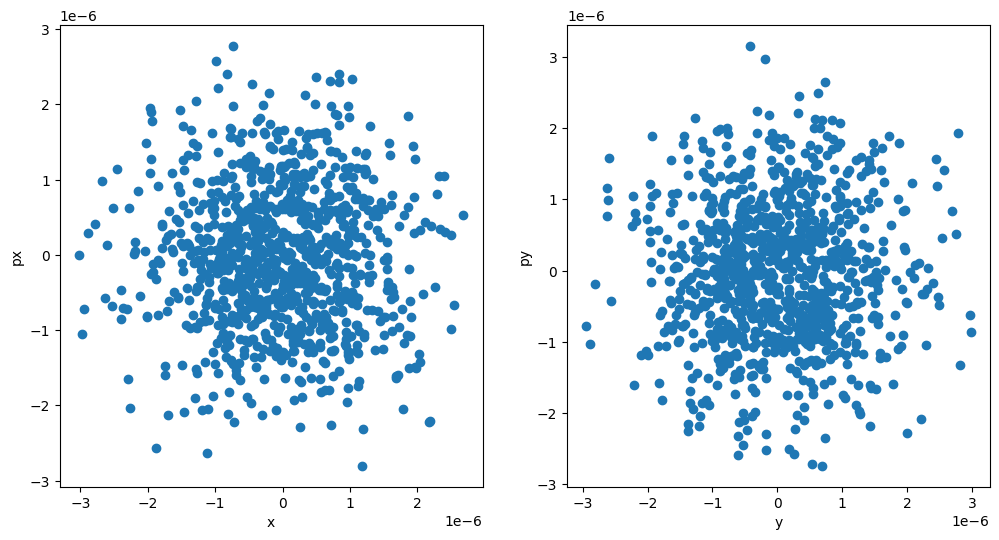

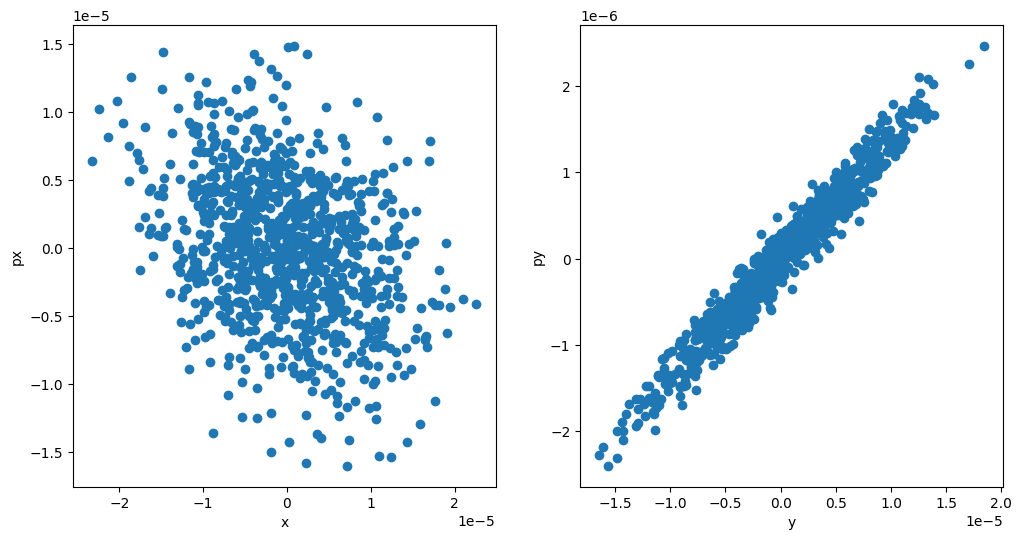

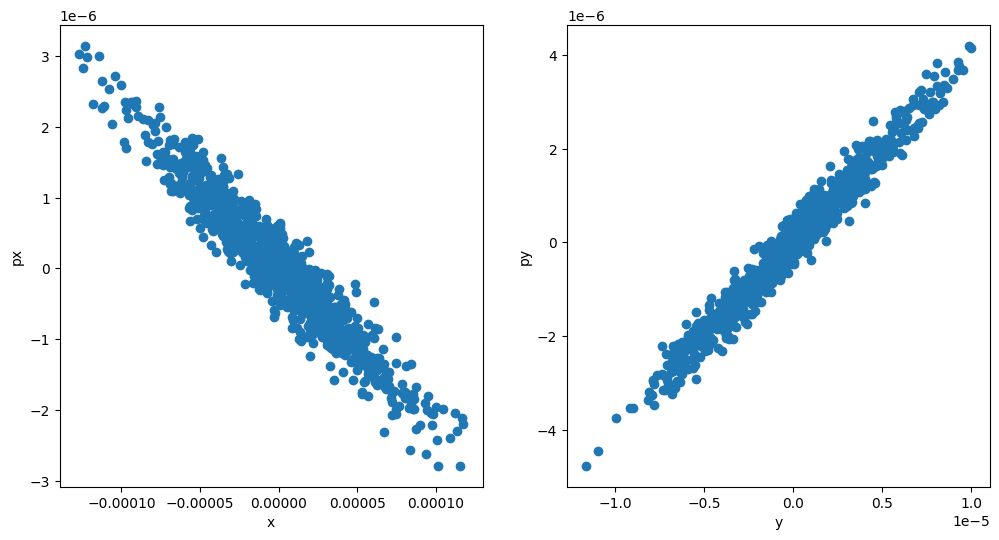

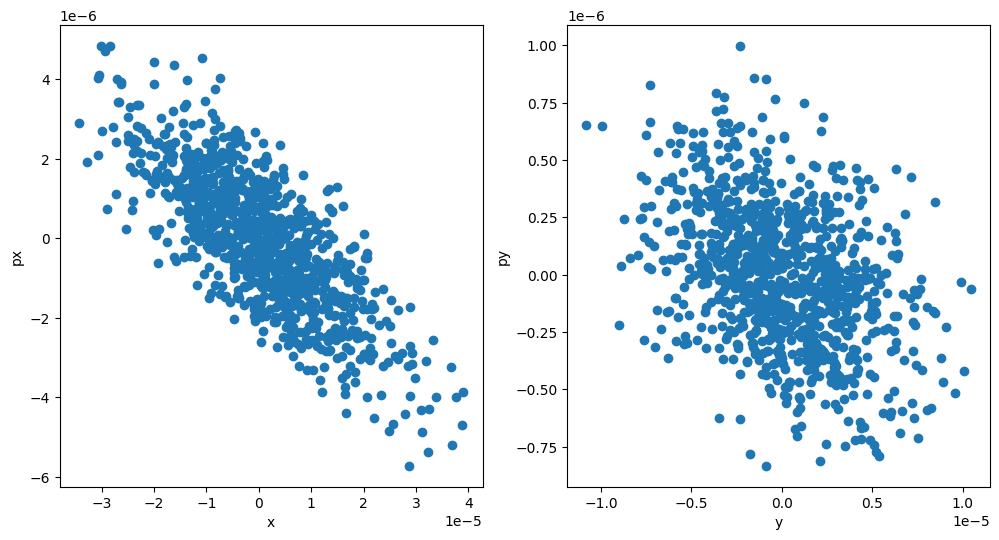

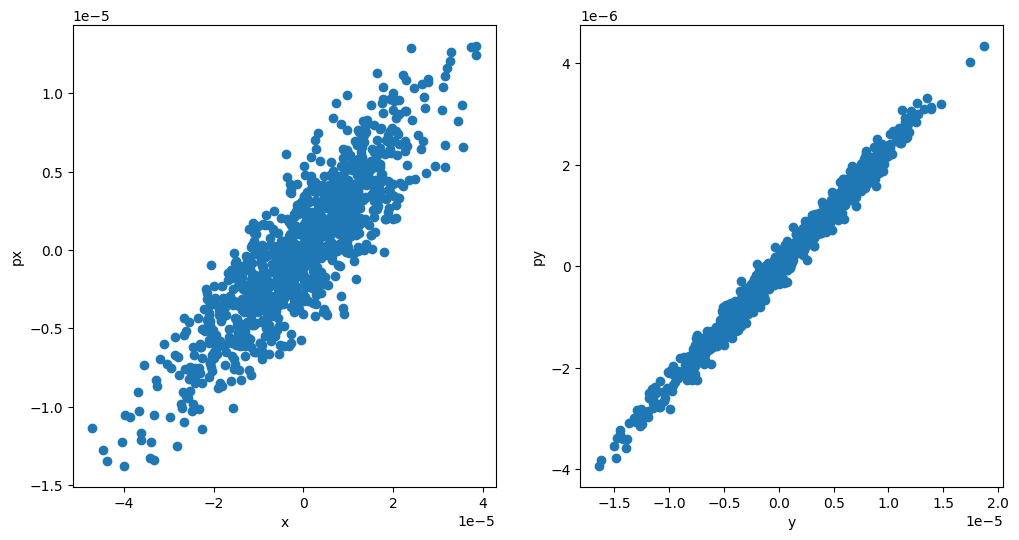

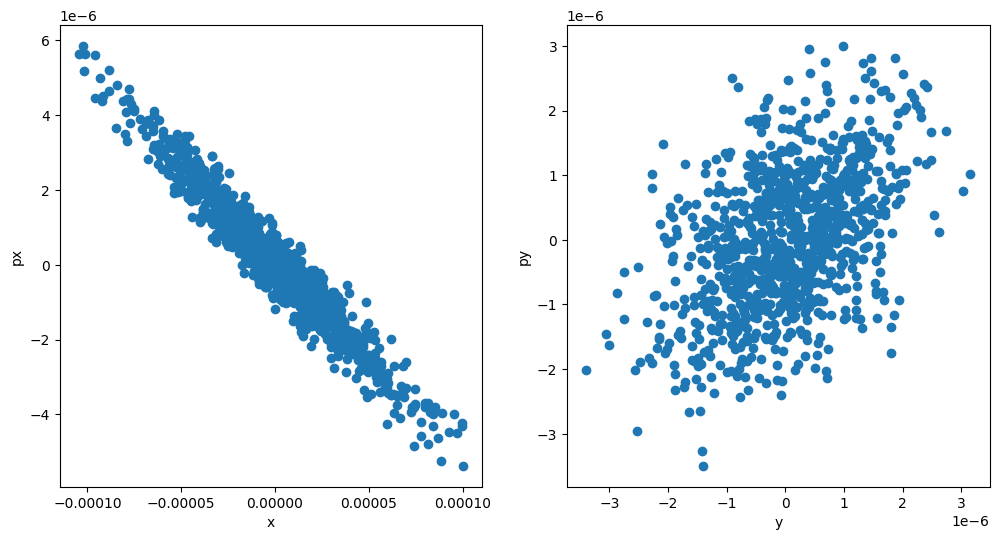

In [40]:
for n in [10]:
    fig, axs = plt.subplots(1,2, figsize=(12,6))
    axs[0].scatter(x_tbt.T[n], px_tbt.T[n])
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("px")
    axs[1].scatter(y_tbt.T[n], py_tbt.T[n])
    axs[1].set_xlabel("y")
    axs[1].set_ylabel("py")
plt.show()

In [90]:
tw = line.twiss(method='4d')

# Inspect tunes and chromaticities
tw.qx # Horizontal tune
tw.qy # Vertical tune
tw.dqx # Horizontal chromaticity
tw.dqy # Vertical chromaticity

np.float64(-4.757332881093701)

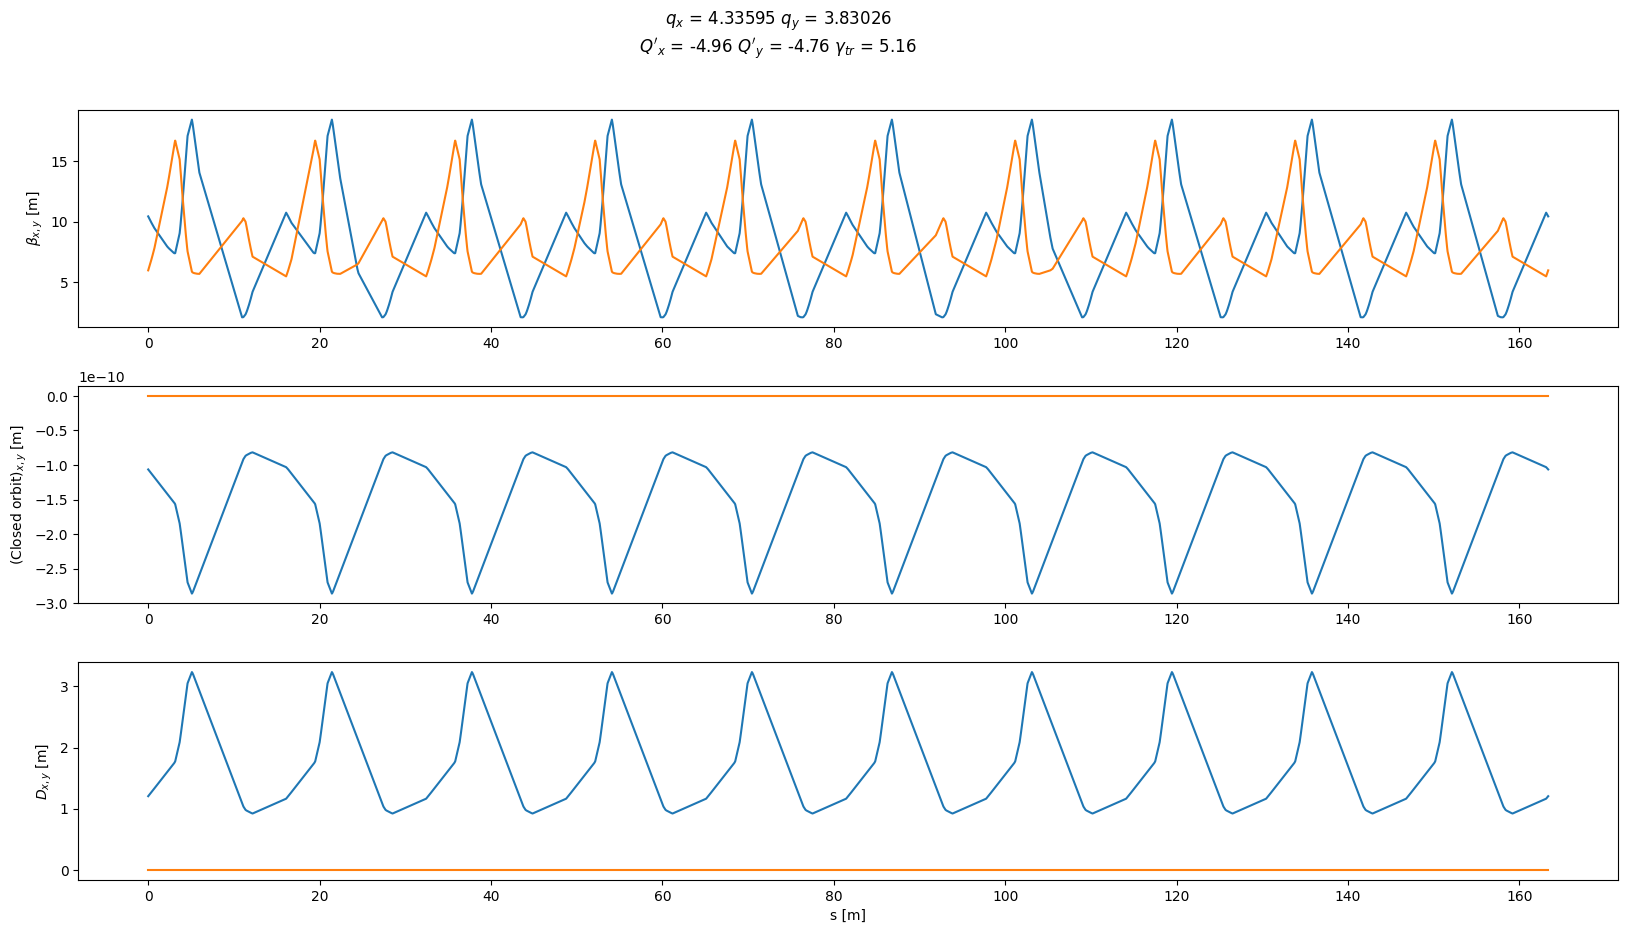

In [92]:
fig1 = plt.figure(1, figsize=(20, 10))
spbet = plt.subplot(3,1,1)
spco = plt.subplot(3,1,2, sharex=spbet)
spdisp = plt.subplot(3,1,3, sharex=spbet)

spbet.plot(tw.s, tw.betx)
spbet.plot(tw.s, tw.bety)
spbet.set_ylabel(r'$\beta_{x,y}$ [m]')

spco.plot(tw.s, tw.x)
spco.plot(tw.s, tw.y)
spco.set_ylabel(r'(Closed orbit)$_{x,y}$ [m]')

spdisp.plot(tw.s, tw.dx)
spdisp.plot(tw.s, tw.dy)
spdisp.set_ylabel(r'$D_{x,y}$ [m]')
spdisp.set_xlabel('s [m]')

fig1.suptitle(
    r'$q_x$ = ' f'{tw.qx:.5f}' r' $q_y$ = ' f'{tw.qy:.5f}' '\n'
    r"$Q'_x$ = " f'{tw.dqx:.2f}' r" $Q'_y$ = " f'{tw.dqy:.2f}'
    r' $\gamma_{tr}$ = '  f'{1/np.sqrt(tw.momentum_compaction_factor):.2f}'
)

fig1.subplots_adjust(left=.15, right=.92, hspace=.27)
plt.show()